# Solving a two-dimensional (cross-sectional) waveguide eigenproblem

We first import all necessary modules and set warnings:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots # Sometimes Necessary for plotting styles
from solver import eigen_top_opt_2D
import pandas as pd

verbose = False
if not verbose:
    import warnings
    warnings.filterwarnings("ignore")

## Parameter initialization

First, we set up the **simulation parameters**:

In [2]:
res  =  0.25  # inverse of resolution
scaling = res*1e-3 # the scale applied to the physical problem
nElx =  int(40/res) # the number of elements in the X axis
nEly =  int(20/res) # the number of elements in the Y axis
nodesX = nElx + 1
nodesY = nEly + 1

Then, we set up the **material parameters**:

In [3]:
# n_metal = 10000 # refractive index for TiN
# k_metal =  0.0  # exctinction coefficient for TiN
# n_back  = 1.0003 # refractive index of the waveguide
# k_back = 0.0 # refractive index of cladding
eps_metal = 10000 **2 # relative permittivity of the metal
eps_back = 1 # relative permittivity of the background medium

Next, we set the **physical parameters**:

In [4]:
wl = 30 / res  # value for the wavelentgth, i.e. 1.55 um.
k = 2 * np.pi / (wl * scaling) # value of the wavevector

In [5]:
print(k)

209.43951023931956


Some checks:

In [6]:
print('Lenght of simulation domain in X: ', nElx*scaling)
print('Lenght of simulation domain in Y: ', nEly*scaling)
print('Wavelength of the problem: ', wl*scaling)
print('Dielectric constant (real part) of metal: ', eps_metal)
print('Dielectric constant (real part) of background: ', eps_back)

Lenght of simulation domain in X:  0.04
Lenght of simulation domain in Y:  0.02
Wavelength of the problem:  0.03
Dielectric constant (real part) of metal:  100000000
Dielectric constant (real part) of background:  1


After, we set the **TopOpt parameters**:

In [7]:
fR = 1  # value for the filtering radius   
eta = 0.5 # parameter that controls threshold value.
beta = 1E9 # parameter that controls threshold sharpness.

Finally, we set the **inital value for the design variables**:

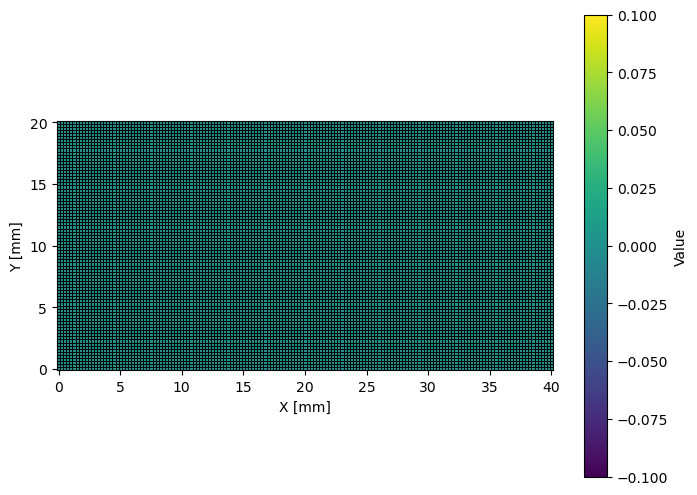

In [8]:
from export import export_mesh
dVini = np.zeros((nodesY, nodesX), dtype=np.float64)
# approx WR159 vs approx WRD150
# ridgeWidth = 9.4e-3
# ridgeHeight = 7.36e-3
# nW = int(ridgeWidth / scaling)
# nH = int(ridgeHeight / scaling)
# dVini[0:nH, nElx//2-nW//2:nElx//2+nW//2] = 1.0
# dVini[nEly-nH:nEly, nElx//2-nW//2:nElx//2+nW//2] = 1.0
x = np.arange(dVini.shape[1]) * scaling * 1000 # Physical x-axis
y = np.arange(dVini.shape[0]) * scaling * 1000 # Physical y-axis

plt.figure(figsize=(8, 6))
plt.pcolormesh(x, y, dVini, edgecolors='k', linewidth=0.5, cmap='viridis')
plt.gca().set_aspect('equal')  # Square cells
plt.colorbar(label='Value')
plt.xlabel("X [mm]")
plt.ylabel("Y [mm]")
plt.show()

# waveguide = np.zeros((nodesY + 2, nodesX + 2), dtype=np.float64)
# waveguide[0, :] = 1.0
# waveguide[-1, :] = 1.0
# waveguide[:, 0] = 1.0
# waveguide[:, -1] = 1.0
# waveguide[1:nEly+1, 1:nElx+1] = dVini
#export_mesh("./Results/Rectangular Waveguide/rect.stl", waveguide, scaling, 100e-3, False)

We initialize the solver:

In [9]:
solver = eigen_top_opt_2D(nElx, 
                          nEly,
                          dVini,
                          eps_metal,
                          eps_back,
                          wl,
                          fR,
                          eta,
                          beta,
                          scaling
                        )

## Eigenmode solution

In [10]:
dVs = np.zeros((nElx*nEly))

Solving eigenvalue problem...
Using SLEPc solver...
Effective index 0: 0.9270 + 0.0000j
Effective index 1: 0.6614 + -0.0000j
Effective index 2: 0.6614 + 0.0000j
Effective index 3: 0.5449 + 0.0000j
Effective index 4: 0.5448 + 0.0000j
Effective index 5: 0.0000 + -0.3536j
Effective index 6: 0.0000 + 0.3538j
Effective index 7: 0.0000 + -0.5157j


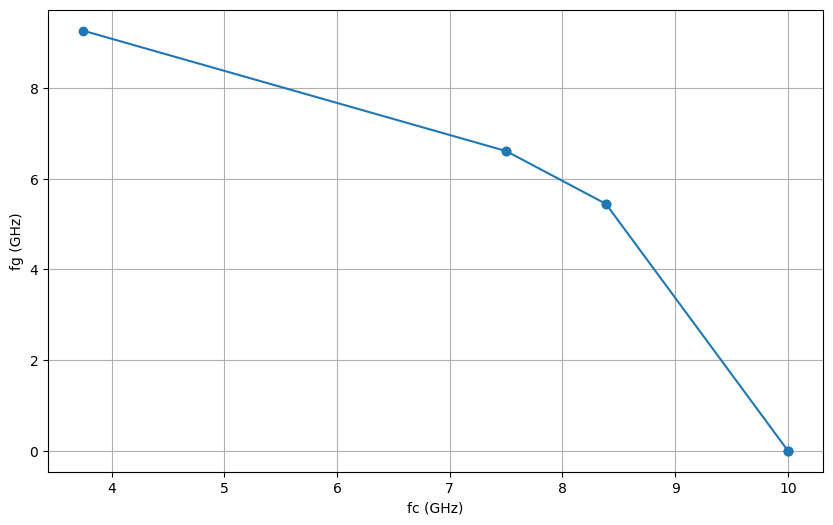

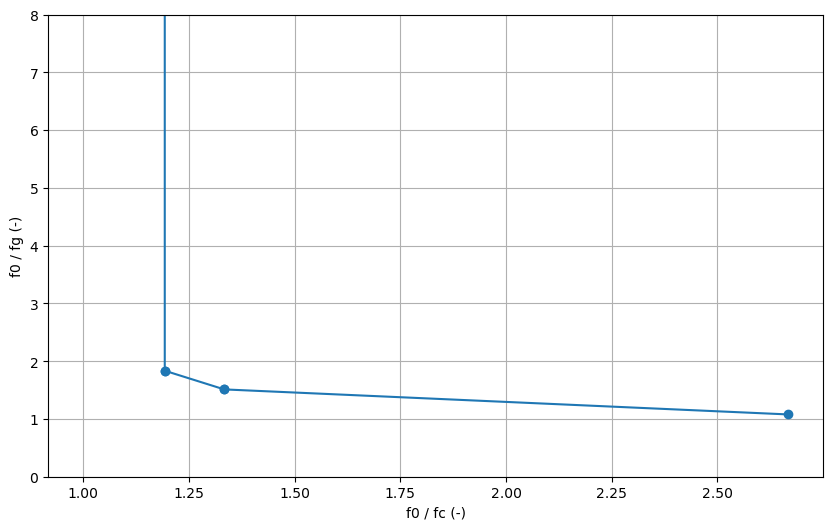

Bandwidth Ratio:  2.0000963835391037


In [11]:
E = solver.solve_forward(dVs)
lambda0 = wl*scaling
f0 = solver.phys.c / lambda0
propWavelengths = 2 * np.pi / np.real(np.sqrt(-E[0]))
propFreqs = solver.phys.c / propWavelengths
cutoffWavelengths = lambda0 / np.sqrt(1 - (lambda0 / propWavelengths)**2)
cutoffFreqs = solver.phys.c / cutoffWavelengths

plt.figure(figsize=(10, 6))
plt.plot(cutoffFreqs / 1e9 , propFreqs / 1e9, 'o-')
plt.ylabel("fg (GHz)")
plt.xlabel("fc (GHz)")
plt.grid(True)
plt.show()
# Create the plot
plt.figure(figsize=(10, 6))
# Customize plot
#plt.xlim(f_min, f_max)
plt.ylim(0, 8)
plt.plot(f0 / cutoffFreqs, f0 / propFreqs, 'o-')
plt.ylabel("f0 / fg (-)")
plt.xlabel("f0 / fc (-)")
plt.grid(True)
plt.show()

cutoffFreqs_sorted = np.sort(cutoffFreqs)
bandwidth_ratio =  cutoffFreqs_sorted[1] / cutoffFreqs_sorted[0]
print("Bandwidth Ratio: ", bandwidth_ratio)
# export cuttoff frequencies
np.savetxt("./Results/Rectangular Waveguide/cutoff_frequencies_FEM.csv", cutoffFreqs, delimiter=",")


Now we plot the normalized fields for the $k$ th eigenvalue:

In [27]:
k = 2
Ex, Ey, Ez = solver.return_mode(k)

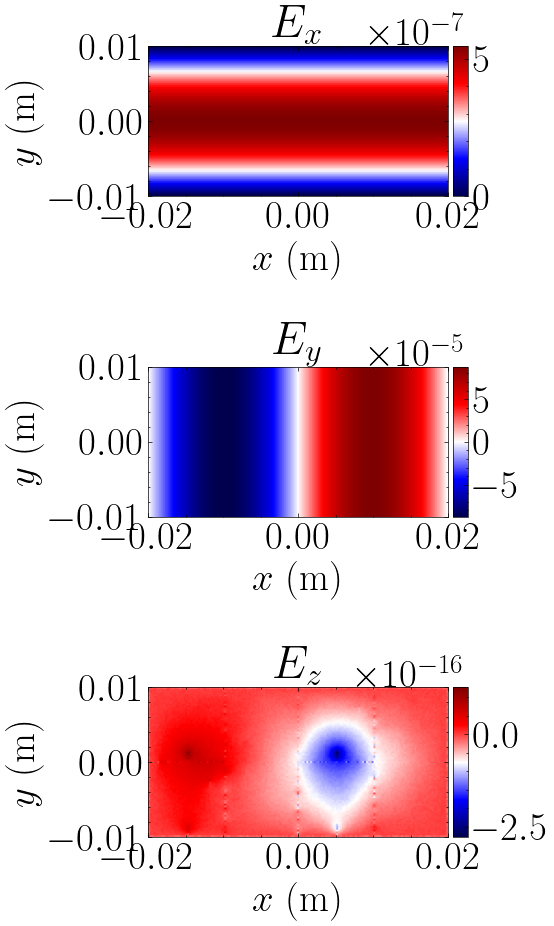

In [28]:
solver.plot_Efields()

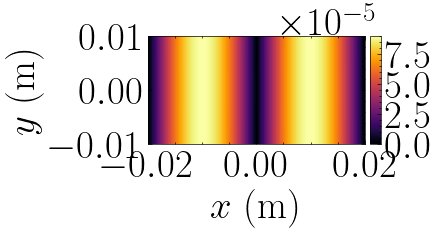

In [29]:
solver.plot_norm()

In [ ]:
solver.plot_E_abs()